<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Communication Systems
</font>
<hr/>
<font color="#800080" size=5>
Assignment 2
<br>
</font>
<font size=5>
Instructor: Dr. Pakravan
<br>
</font>
<font size=4>
Fall 2025
<br>
</font>

<hr>
<br>
</font>
<font face="Times New Roman" size=4 align=center>
Feel free to ask your questions in Telegram : @YadollahiAlii
</font>
<br>
<hr>
</div></font>

Name = "Amitis Mirabedini"

StudentId = "402102562"

# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz
from scipy.fft import fft, ifft, fftshift, fftfreq
from numpy.linalg import pinv
import scipy.stats as stats

# Question 1: Amplitude Modulation


Consider the following signal


$
m(t) = e^{-6t}\bigl[u(t-4) - u(t-8)\bigr]
     + e^{6t}\bigl[u(-t-4) - u(-t-8)\bigr]
$



## Task 1.1
First, plot the signal in the time and frequency domains and declare its bandwidth; Then
sample the signal at an appropriate rate. Explain how this rate is obtained.

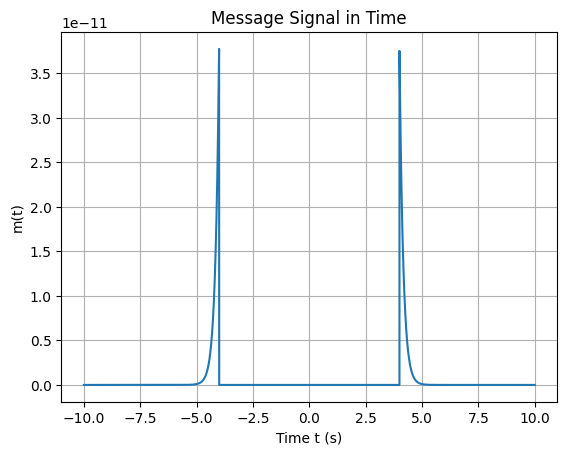

C:\Users\Notebook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Notebook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


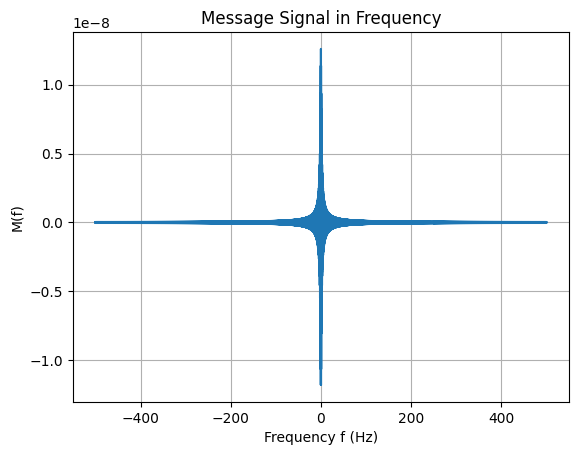

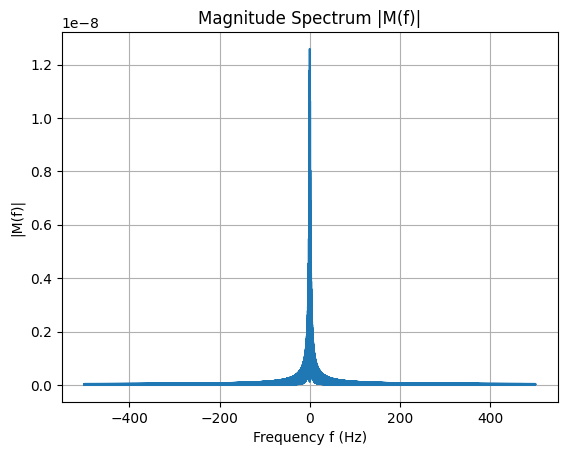

In [2]:
dt = 0.001
t = np.arange(-10, 10 + dt, dt)
m1 = np.exp(-6 * t)
m2 = np.exp(6 * t)
T01, T02, T03, T04 = 4, 8, -4, -8
u1 = (t >= T01).astype(float)
u2 = (t >= T02).astype(float)
u3 = (t <= T03).astype(float)
u4 = (t <= T04).astype(float)
message = m1 * (u1 - u2) + m2 * (u3 - u4)
#1) Plotting the message signal in time
plt.figure()
plt.plot(t, message)
plt.xlabel('Time t (s)')
plt.ylabel('m(t)') 
plt.title('Message Signal in Time')
plt.grid(True)
plt.show()
#2) Plotting the message signal in frequency
N = len(message)
M = fft(message)
f = fftfreq(N, dt)
M_shifted = fftshift(M)
f_shifted = fftshift(f)
plt.figure()
plt.plot(f_shifted, M_shifted)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('M(f)')
plt.title('Message Signal in Frequency')
plt.grid(True)
plt.show()
#3) Plotting the message signal Magnitude Specturm
M_mag = np.abs(M_shifted)
plt.figure()
plt.plot(f_shifted, M_mag)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('|M(f)|')
plt.title('Magnitude Spectrum |M(f)|')
plt.grid(True)
plt.show()



### How is the sampling rate obtained?
By trying different dt's in the formula we have used in plotting the code in time domain and seeing the results and also by paying attention to the Nyquist criterion which states that the sampling rate must be at least twice the bandwidth of our signal for the signal to be sampled correctly and prevent aliasing. We decide that dt must be 0.001 and so our sampling rate should be 1000Hz, so that our signal in time is plotted correctly(by using less dt's we see that the value of the signal in 4 and -4 in time is not the same which is not the case here), and also we have chosen the sampling rate high enough that it matches with the Nyquist criterion as well.

## Task 1.2
By defining suitable parameters, modulate this signal with AM modulation. Plot the modulated
signal and its spectrum.

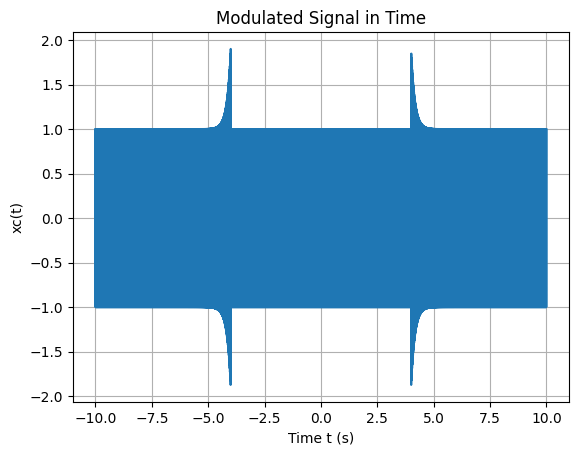

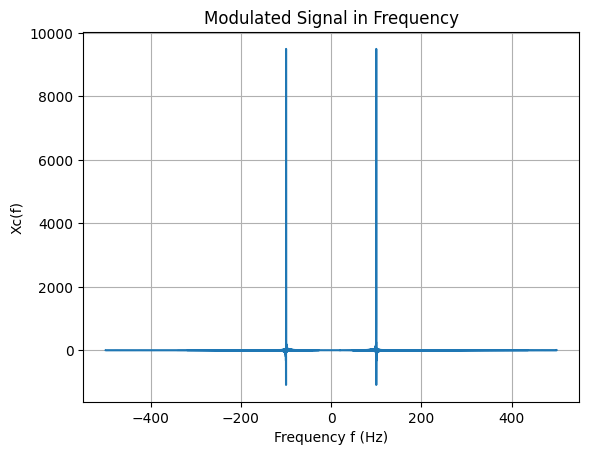

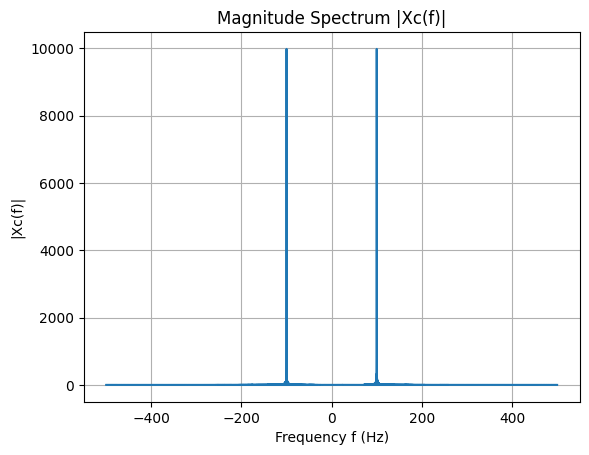

In [3]:
# Task 1.2
message = message / np.max(message)
mu, Ac, fc = 0.9, 1, 100
t1 = np.arange(-10, 10 + dt, dt)
xc = Ac * (1 + mu*message) * np.cos(2*np.pi*fc*t1)
#1) Plotting the modulated signal in time domain
plt.figure()
plt.plot(t1, xc)
plt.xlabel('Time t (s)')
plt.ylabel('xc(t)') 
plt.title('Modulated Signal in Time')
plt.grid(True)
plt.show()
#2) Plotting the modulated signal in frequency
N = len(xc)
M = fft(xc)
f = fftfreq(N, dt)
M_shifted = fftshift(M)
f_shifted = fftshift(f)
plt.figure()
plt.plot(f_shifted, M_shifted)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('Xc(f)')
plt.title('Modulated Signal in Frequency')
plt.grid(True)
plt.show()
#3) Plotting the message signal Magnitude Specturm
M_mag = np.abs(M_shifted)
plt.figure()
plt.plot(f_shifted, M_mag)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('|Xc(f)|')
plt.title('Magnitude Spectrum |Xc(f)|')
plt.grid(True)
plt.show()


## Task 1.3
The circuit shown in the following figure is the simplest circuit to detect the signal envelope. Introduce the
time constant and explain its effect on the output corresponding to this circuit. What effect
do you think putting a resistor in series with a diode has on the output?

![fig1:Envelope Detector](fig1.png)


The time constant here is tau = RC, the higher the multiplication of R and C is the slower would be the speed of discharging of the capacitor and so it would take a long time for it to decay and when RC or the time constant is too large we won't catch everypoint and we will jump from them hence true Demodulation can't happen.  
If RC is low, then the speed of the discharge of our capacitor gets high, hence it takes only a short amount of time for our decay and we would have a lot of distortion here.
Here when diode is on, the wire is passing the current and so the capacitor is being charged and almost no current is passing through the resistor, when the diode is off, our capacitor starts discharging in the loop between itself and the Resistor so Cv starts dropping. If we choose RC correctly then this dropping will take an appropriate amount of time and so our envelope detector will work properly.

## Task 1.4
Write a function that takes the input signal, the time constant and the initial value of the
output and gives the corresponding output. (for the detector in the previous part)

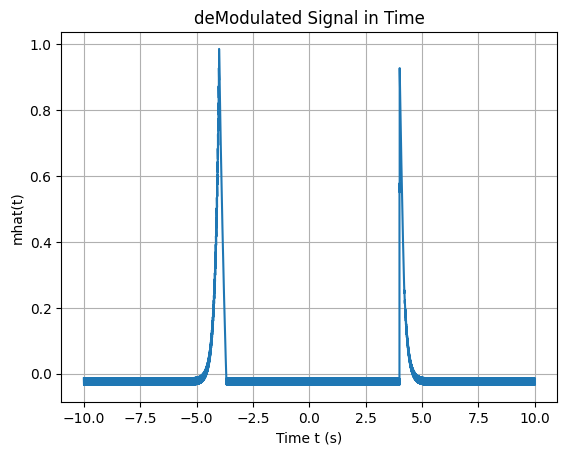

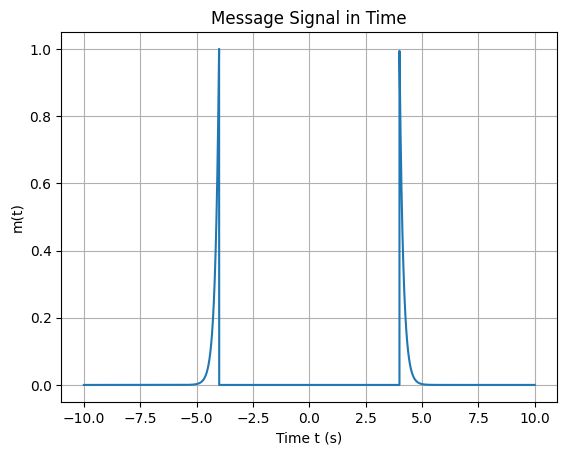

In [4]:
# Task 1.4
def Am_Envelope(R, C, fs, initial):
    out = np.zeros_like(initial)
    out[0] = initial[0]
    for t in range(1, len(initial)):
        out[t] = max(initial[t], out[t-1] * np.exp(-1/(fs*R*C)))

    return out

R = 10
C = 0.05
push = Am_Envelope(R, C, 1000, xc)
mhat = push - np.mean(push)
mhat = mhat/mu

plt.figure()
plt.plot(t1, mhat)
plt.xlabel('Time t (s)')
plt.ylabel('mhat(t)') 
plt.title('deModulated Signal in Time')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t1, message)
plt.xlabel('Time t (s)')
plt.ylabel('m(t)') 
plt.title('Message Signal in Time')
plt.grid(True)
plt.show()






Attention : The message signal has been normalized by dividing the message signal by it's max so we would have a better and more understandable figure to analyze.

# Task 1.5
Demodulate the modulated signal with a coherent detector shown in the figure

![fig2:Coherent Detector](fig2.png)

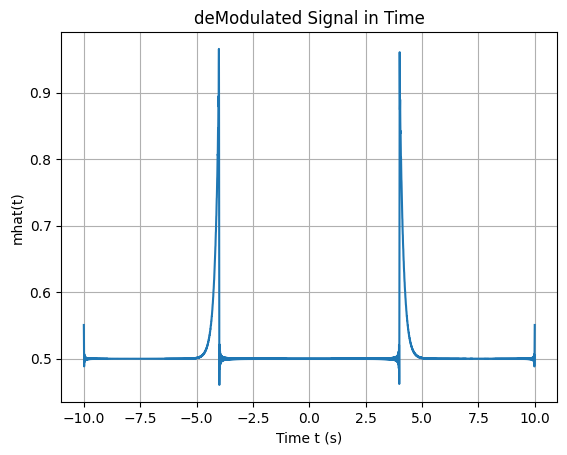

In [5]:
# Task 1.5
xprimec = xc * np.cos(2 * np.pi * fc * t)
N = len(xprimec)
M = fft(xprimec)
f = fftfreq(N, dt)
M_shifted = fftshift(M)
f_shifted = fftshift(f)


cutoff_freq = fc/2
filter_shifted = np.zeros_like(M_shifted, dtype = complex)
filter_shifted[np.abs(f_shifted) <= cutoff_freq] = 1
M_filtered_shifted = M_shifted * filter_shifted
M_filtered = np.fft.ifftshift(M_filtered_shifted)
mhat = np.fft.ifft(M_filtered)
mhat = mhat.real

plt.figure()
plt.plot(t, mhat)
plt.xlabel('Time t (s)')
plt.ylabel('mhat(t)') 
plt.title('deModulated Signal in Time')
plt.grid(True)
plt.show()

## Task 1.6
Compare the output of these two methods together and with the original signal. Which of
these 2 demodulation methods perform more accurate?

In here because the fc that we are using has not changed in the coherent detection and we are in a simulation space we can't see that much of a difference between the accuracy of coherent detector and the envelope detector. In real-world applications because fc doesn't necessarily stay the same for demodualtion there is absolutely no guarantee that we have demodulated the signal properly and then synchronization comes in, but in general we can say that in this case envelope detector will work better if we choose an appropriate value for the time constant RC and also the coherent detector is performing ok because fc is not changing.

## Task 1.7
Modulate the primary signal using the Upper Single Side Band (USSB) method and create time
and frequency domain plots. Then, demodulate the signal using the coherence demodulation
method and generate time and frequency domain plots for the demodulated signal.

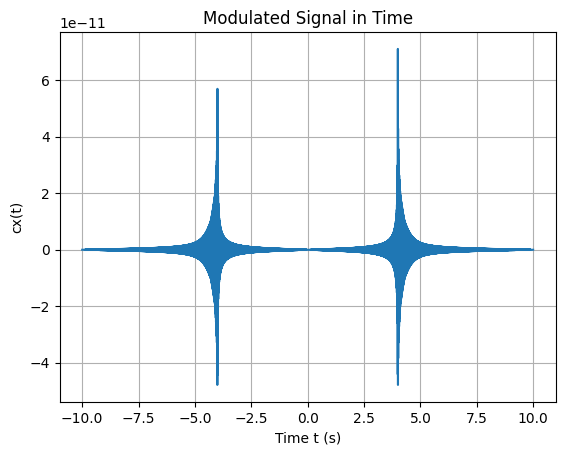

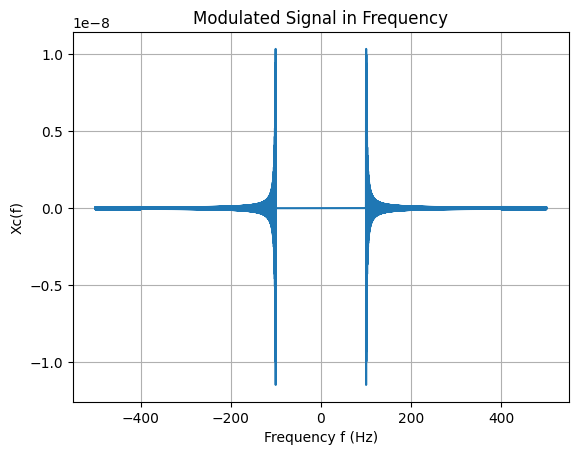

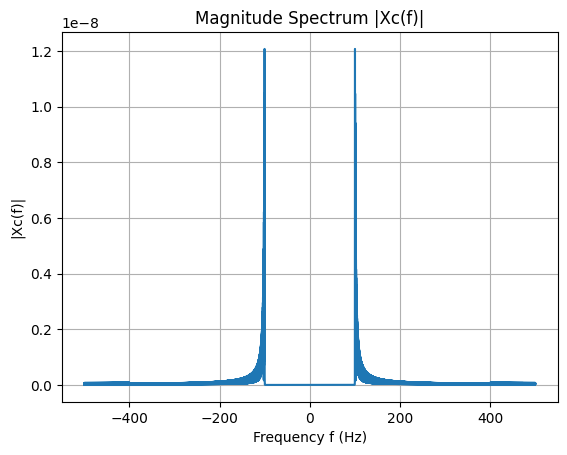

In [6]:
# Task 1.7
from scipy.signal import hilbert
dt = 0.001
t = np.arange(-10, 10 + dt, dt)
m1 = np.exp(-6 * t)
m2 = np.exp(6 * t)
T01, T02, T03, T04 = 4, 8, -4, -8
u1 = (t >= T01).astype(float)
u2 = (t >= T02).astype(float)
u3 = (t <= T03).astype(float)
u4 = (t <= T04).astype(float)
message = m1 * (u1 - u2) + m2 * (u3 - u4)
message_hilbert = hilbert(message).imag
fc = 100
omega_c = 2 * np.pi * fc
carrier_cos = np.cos(omega_c * t)
carrier_sin = np.sin(omega_c * t)
ussb_signal = message * carrier_cos - message_hilbert * carrier_sin

plt.figure()
plt.plot(t1, ussb_signal)
plt.xlabel('Time t (s)')
plt.ylabel('cx(t)') 
plt.title('Modulated Signal in Time')
plt.grid(True)
plt.show()
#2) Plotting the modulated signal in frequency
N = len(ussb_signal)
M = fft(ussb_signal)
f = fftfreq(N, dt)
M_shifted = fftshift(M)
f_shifted = fftshift(f)
plt.figure()
plt.plot(f_shifted, M_shifted)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('Xc(f)')
plt.title('Modulated Signal in Frequency')
plt.grid(True)
plt.show()
#3) Plotting the modulated signal Magnitude Specturm
M_mag = np.abs(M_shifted)
plt.figure()
plt.plot(f_shifted, M_mag)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('|Xc(f)|')
plt.title('Magnitude Spectrum |Xc(f)|')
plt.grid(True)
plt.show()



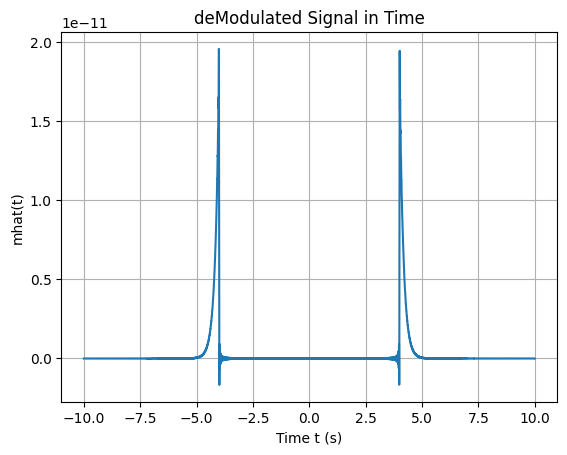

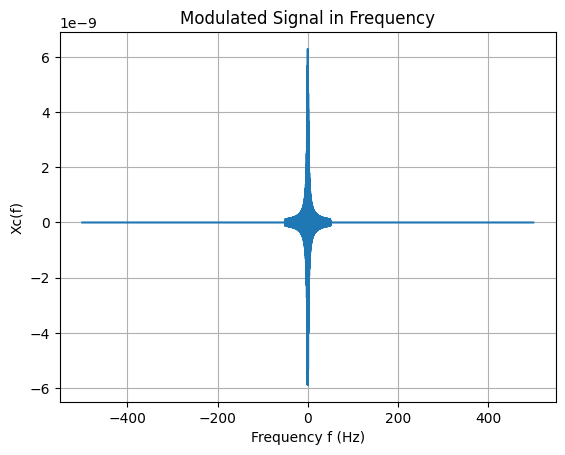

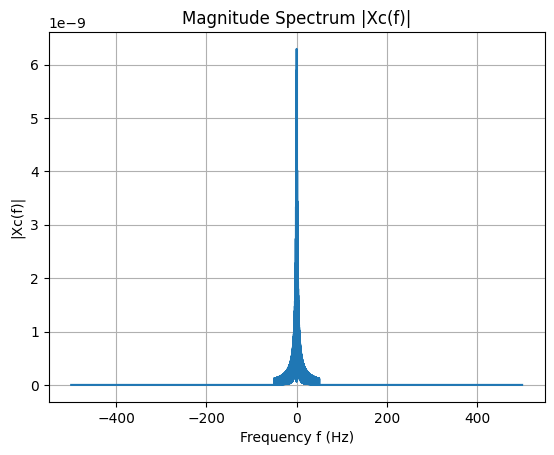

In [7]:
xprimec = ussb_signal * np.cos(2 * np.pi * fc * t)
N = len(xprimec)
M = fft(xprimec)
f = fftfreq(N, dt)
M_shifted = fftshift(M)
f_shifted = fftshift(f)


cutoff_freq = fc/2
filter_shifted = np.zeros_like(M_shifted, dtype = complex)
filter_shifted[np.abs(f_shifted) <= cutoff_freq] = 1
M_filtered_shifted = M_shifted * filter_shifted
M_filtered = np.fft.ifftshift(M_filtered_shifted)
mhat = np.fft.ifft(M_filtered)
mhat = mhat.real

plt.figure()
plt.plot(t, mhat)
plt.xlabel('Time t (s)')
plt.ylabel('mhat(t)') 
plt.title('deModulated Signal in Time')
plt.grid(True)
plt.show()

#2) Plotting the demodulated signal in frequency
N = len(mhat)
M = fft(mhat)
f = fftfreq(N, dt)
M_shifted = fftshift(M)
f_shifted = fftshift(f)
plt.figure()
plt.plot(f_shifted, M_shifted)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('Xc(f)')
plt.title('Modulated Signal in Frequency')
plt.grid(True)
plt.show()
#3) Plotting the demodulated message signal Magnitude Specturm
M_mag = np.abs(M_shifted)
plt.figure()
plt.plot(f_shifted, M_mag)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('|Xc(f)|')
plt.title('Magnitude Spectrum |Xc(f)|')
plt.grid(True)
plt.show()


## Task 1.8
Repeat the previous part for LSSB modulation.


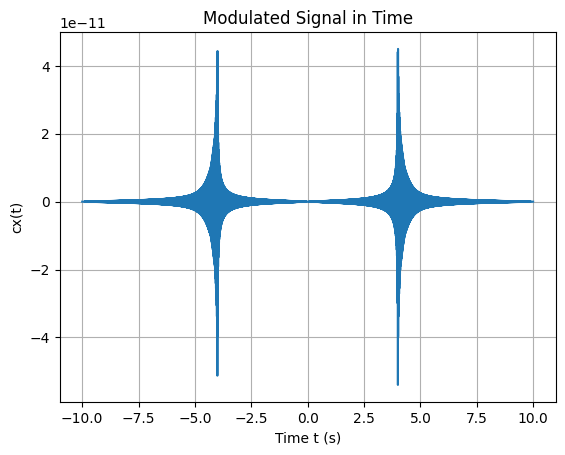

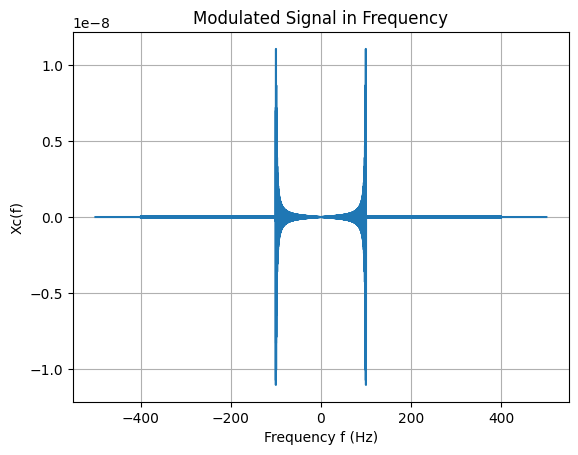

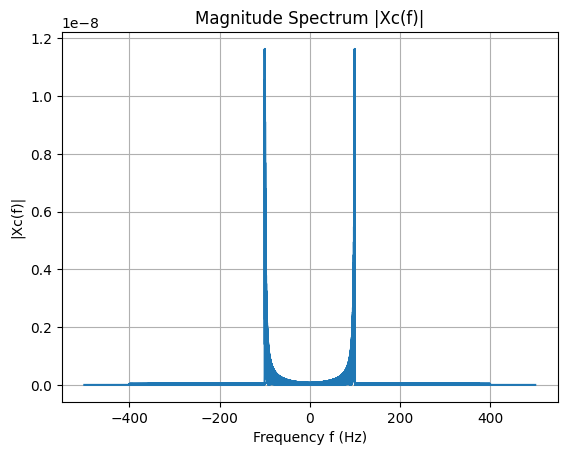

In [8]:
# Task 1.8
from scipy.signal import hilbert
dt = 0.001
t = np.arange(-10, 10 + dt, dt)
m1 = np.exp(-6 * t)
m2 = np.exp(6 * t)
T01, T02, T03, T04 = 4, 8, -4, -8
u1 = (t >= T01).astype(float)
u2 = (t >= T02).astype(float)
u3 = (t <= T03).astype(float)
u4 = (t <= T04).astype(float)
message = m1 * (u1 - u2) + m2 * (u3 - u4)
message_hilbert = hilbert(message).imag
fc = 100
omega_c = 2 * np.pi * fc
carrier_cos = np.cos(omega_c * t)
carrier_sin = np.sin(omega_c * t)
lssb_signal = message * carrier_cos + message_hilbert * carrier_sin

plt.figure()
plt.plot(t1, lssb_signal)
plt.xlabel('Time t (s)')
plt.ylabel('cx(t)') 
plt.title('Modulated Signal in Time')
plt.grid(True)
plt.show()
#2) Plotting the modulated signal in frequency
N = len(lssb_signal)
M = fft(lssb_signal)
f = fftfreq(N, dt)
M_shifted = fftshift(M)
f_shifted = fftshift(f)
plt.figure()
plt.plot(f_shifted, M_shifted)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('Xc(f)')
plt.title('Modulated Signal in Frequency')
plt.grid(True)
plt.show()
#3) Plotting the modulated signal Magnitude Specturm
M_mag = np.abs(M_shifted)
plt.figure()
plt.plot(f_shifted, M_mag)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('|Xc(f)|')
plt.title('Magnitude Spectrum |Xc(f)|')
plt.grid(True)
plt.show()



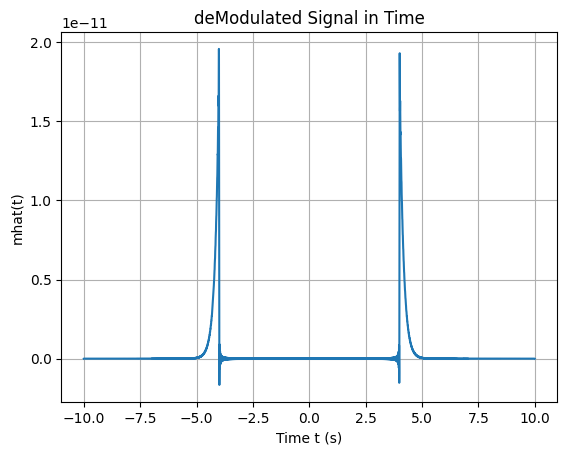

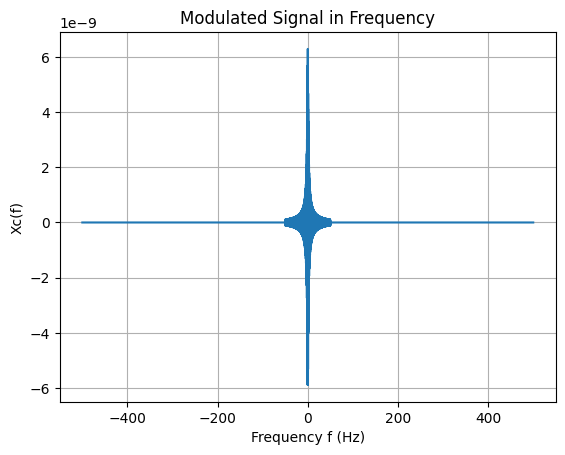

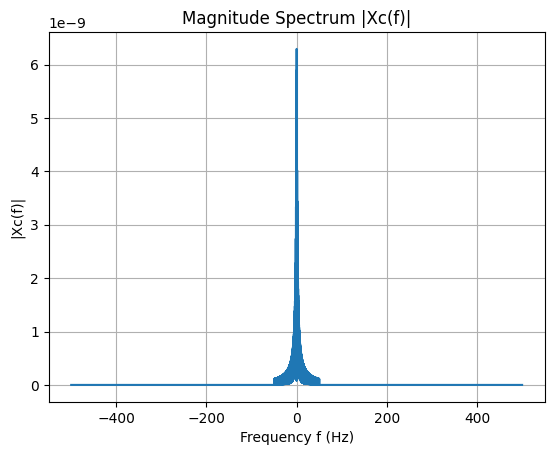

In [9]:
xprimec = lssb_signal * np.cos(2 * np.pi * fc * t)
N = len(xprimec)
M = fft(xprimec)
f = fftfreq(N, dt)
M_shifted = fftshift(M)
f_shifted = fftshift(f)


cutoff_freq = fc/2
filter_shifted = np.zeros_like(M_shifted, dtype = complex)
filter_shifted[np.abs(f_shifted) <= cutoff_freq] = 1
M_filtered_shifted = M_shifted * filter_shifted
M_filtered = np.fft.ifftshift(M_filtered_shifted)
mhat = np.fft.ifft(M_filtered)
mhat = mhat.real

plt.figure()
plt.plot(t, mhat)
plt.xlabel('Time t (s)')
plt.ylabel('mhat(t)') 
plt.title('deModulated Signal in Time')
plt.grid(True)
plt.show()

#2) Plotting the demodulated signal in frequency
N = len(mhat)
M = fft(mhat)
f = fftfreq(N, dt)
M_shifted = fftshift(M)
f_shifted = fftshift(f)
plt.figure()
plt.plot(f_shifted, M_shifted)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('Xc(f)')
plt.title('Modulated Signal in Frequency')
plt.grid(True)
plt.show()
#3) Plotting the demodulated message signal Magnitude Specturm
M_mag = np.abs(M_shifted)
plt.figure()
plt.plot(f_shifted, M_mag)
plt.xlabel('Frequency f (Hz)')
plt.ylabel('|Xc(f)|')
plt.title('Magnitude Spectrum |Xc(f)|')
plt.grid(True)
plt.show()


## Task 1.9
Compare the original message with the AM, USSB, and LSSB output and explain the reason
for the difference. Also, compare the advantages and disadvantages of these three modulation
methods.

AM transmits a carrier + both sidebands which wastes power and bandwidth  
USSB and LSSB suppress the carrier and one sideband which is efficient but complex.  
AM is Simple, robust for low-cost receivers, Demodulation is easier in AM than that of in SSB.  
It is easy to produce convetional AM signals at high power levels so these can be used for broadcastinf services, cheap at low cost. SSB syste,s require less power to transmit the same info, as in conventional AM larger power(66%) is wasted in carrier that contains no info. SSB requires more complex coherent receivers which are used mostly in point to point communication systems. Also SSB has 50% bandwidth saving becuase it requires half the bandwidth of what is required in AM.  

## Task 1.10 (Bonus)
Use a microphone to record your voice. Then, apply the AM modulation method
that you used in the second part of this question to your speech signal and plot the spectrum
of the modulated signal. Next, use the two demodulation methods that you studied in the
question to recover your speech signal and compare the outputs

In [88]:
# Task 1.10
import soundfile as sf


ModuleNotFoundError: No module named 'soundfile'

# Question 2: Frequency Modulation
In this section, we want to obtain the sent message from its FM modulated signal with three
methods. We call the sent message $m(t)$ and we have:

$m(t) = \sin(25\pi t), \quad 0 \le t \le 1$          


## Task 2.1
Sample this message at $fs$ = 10 kHz and obtain the FM signal with the following values.

$
x_c(t) = A_c \cos\!\left( 2\pi f_c t + 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau \right)
\quad
$
$
(A_c = 1,\; f_c = 200~\text{Hz},\; f_{\Delta} = 30~\text{Hz/V})
$


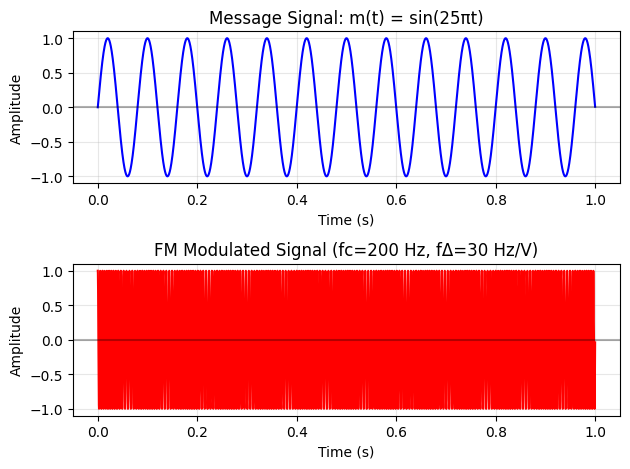

FM Signal Generated Successfully!
  - Message frequency (fm): 12.50 Hz
  - Modulation index (β): 2.40 (fΔ/fm = 30/12.5)
  - Carrier frequency: 200 Hz
  - Sampling rate: 10000 Hz
  - Signal length: 10000 samples


In [10]:
# Task 2.1
Ac, fc, f_delta, fs, t_max = 1, 200, 30, 10000, 1
t = np.arange(0, t_max, 1/fs)
m_t = np.sin(25 * np.pi * t)
dt = 1/fs
integral = np.cumsum(m_t) * dt
phase = 2 * np.pi * fc * t + 2 * np.pi * f_delta * integral
fm_signal = Ac * np.cos(phase)

# Message signal
plt.subplot(2, 1, 1)
plt.plot(t, m_t, 'b', linewidth=1.5)
plt.title('Message Signal: m(t) = sin(25πt)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='-', alpha=0.3)

# FM modulated signal
plt.subplot(2, 1, 2)
plt.plot(t, fm_signal, 'r', linewidth=1.5)
plt.title('FM Modulated Signal (fc=200 Hz, fΔ=30 Hz/V)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig('fm_signal.png', dpi=300)
plt.show()

modulation_index = f_delta / (25 * np.pi / (2 * np.pi))  # β = fΔ / fm
print(f"FM Signal Generated Successfully!")
print(f"  - Message frequency (fm): {25*np.pi/(2*np.pi):.2f} Hz")
print(f"  - Modulation index (β): {modulation_index:.2f} (fΔ/fm = 30/12.5)")
print(f"  - Carrier frequency: {fc} Hz")
print(f"  - Sampling rate: {fs} Hz")
print(f"  - Signal length: {len(t)} samples")



## Task 2.2
With the help of _scipy.signal.detrend_ and _scipy.signal.hilbert_ command, restore the
message signal ideally.

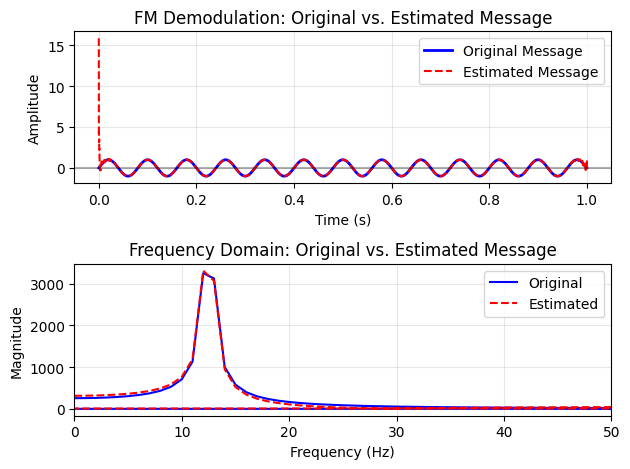

✅ FM Demodulation Complete!
  - Modulation index (β): 2.40 (30/12.5)
  - Mean Squared Error (MSE): 0.043309
  - Signal-to-Noise Ratio (SNR): 10.62 dB


In [11]:
# Task 2.2
from scipy import signal
analytic_signal = signal.hilbert(fm_signal)
phase = np.unwrap(np.angle(analytic_signal))
phase_detrended = signal.detrend(phase, type = 'linear')
dt = 1/fs
m_est = np.gradient(phase_detrended, dt) / (2 * np.pi * f_delta)
# Original message
plt.subplot(2, 1, 1)
plt.plot(t, m_t, 'b', linewidth=2, label='Original Message')
plt.plot(t, m_est, 'r--', linewidth=1.5, label='Estimated Message')
plt.title('FM Demodulation: Original vs. Estimated Message')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axhline(0, color='k', linestyle='-', alpha=0.3)

plt.subplot(2, 1, 2)
fft_orig = np.fft.fft(m_t)
fft_est = np.fft.fft(m_est)
freq = np.fft.fftfreq(len(t), 1/fs)

plt.plot(freq, np.abs(fft_orig), 'b', label='Original')
plt.plot(freq, np.abs(fft_est), 'r--', label='Estimated')
plt.title('Frequency Domain: Original vs. Estimated Message')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, 50)  # Focus on message bandwidth (12.5 Hz)

plt.tight_layout()
plt.savefig('fm_demodulation.png', dpi=300)
plt.show()

mse = np.mean((m_t - m_est)**2)
print(f"✅ FM Demodulation Complete!")
print(f"  - Modulation index (β): {f_delta / (25*np.pi/(2*np.pi)):.2f} (30/12.5)")
print(f"  - Mean Squared Error (MSE): {mse:.6f}")
print(f"  - Signal-to-Noise Ratio (SNR): {10*np.log10(np.var(m_t)/mse):.2f} dB")





## Task 2.3
Taking the derivative of the signal $x_c(t)$ we will have:
$
x_d(t) = \frac{d x_c(t)}{d t} = -A_c \bigl(2\pi f_c + 2\pi f_{\Delta} m(t)\bigr)
\sin\!\left( 2\pi f_c t + 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau \right)
$
If the frequency changes $\sin\!\left( 2\pi f_c t + 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau \right)$ of the signal due to the message $m(t)$ are ignored compared to the frequency $f_c$, we can consider the $x_d$ signal as an AM signal whose envelope contains the desired message. Restore the message using the Envelope Detector made in the first problem with new values for the resistor and capacitor.


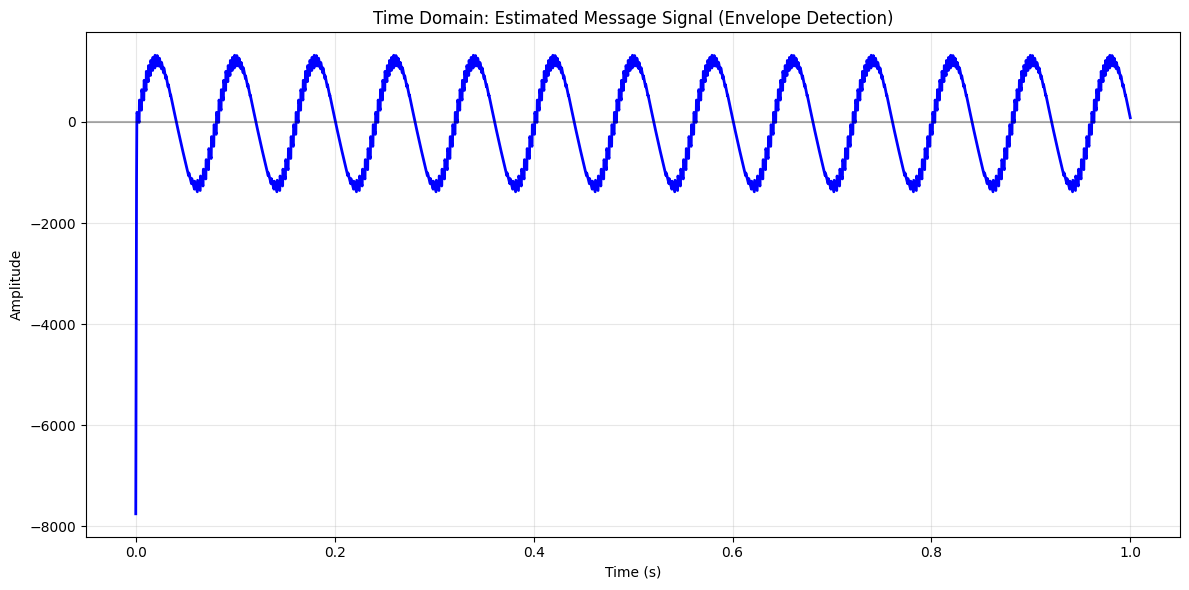

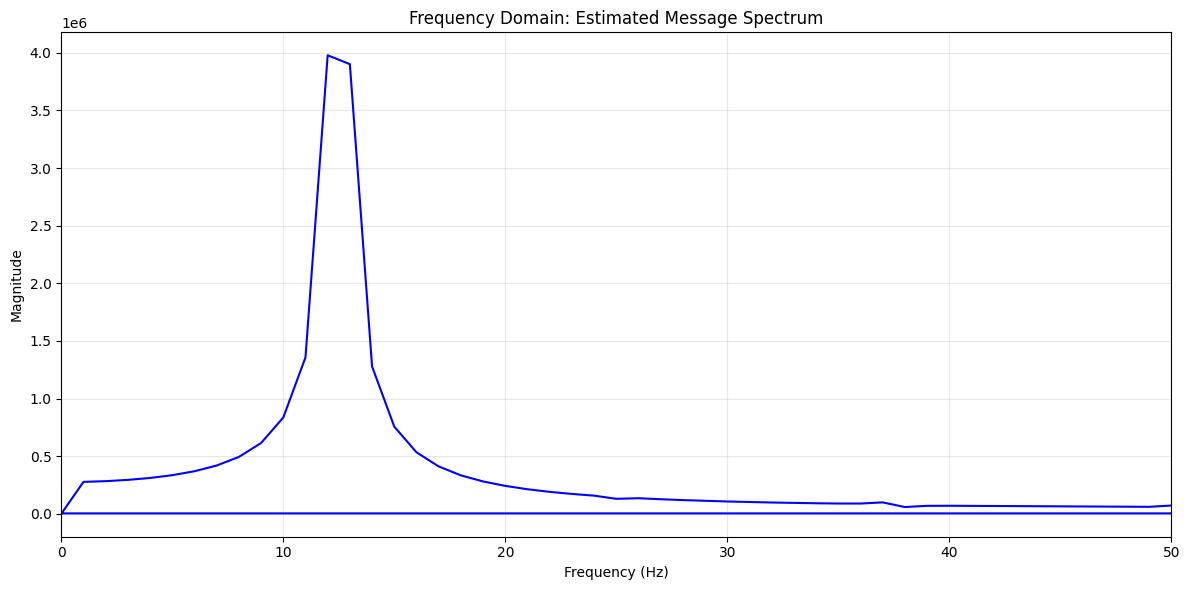

In [12]:
# Task 2.3
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


Ac = 1.0
fc = 200
f_delta = 30
fs = 10000
t = np.arange(0, 1, 1/fs)
m_t = np.sin(25 * np.pi * t)  

phase = 2 * np.pi * fc * t + 2 * np.pi * f_delta * np.cumsum(m_t) * (1/fs)
fm_signal = Ac * np.cos(phase)

# ======================
# TASK 2.3: ENVELOPE DETECTION ON DERIVATIVE
# ======================
# 1. Compute derivative x_d(t) = d(x_c)/dt
x_d = np.gradient(fm_signal, 1/fs) 

# 2. Take absolute value (for envelope detection)
x_d_abs = np.abs(x_d)

# 3. Envelope detector parameters
R = 1800
C = 50e-6  
tau = R * C 



# 5. Apply envelope detector
envelope = Am_Envelope(R, C, fs, x_d_abs)

envelope_dc_removed = envelope - np.mean(envelope)
m_est = envelope_dc_removed * (fc / f_delta)  # Scale by f_c/f_Δ

# ======================
# PLOT RESULTS
# ======================
plt.figure(figsize=(12, 6))
plt.plot(t, m_est, 'b', linewidth=2)
plt.title('Time Domain: Estimated Message Signal (Envelope Detection)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig('time_domain_estimated.png', dpi=300)
plt.show()

plt.figure(figsize=(12, 6))
fft_est = np.fft.fft(m_est)
freq = np.fft.fftfreq(len(t), 1/fs)

plt.plot(freq, np.abs(fft_est), 'b')
plt.title('Frequency Domain: Estimated Message Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)
plt.xlim(0, 50)  # Focus on message bandwidth (12.5 Hz)
plt.tight_layout()
plt.savefig('frequency_domain_estimated.png', dpi=300)
plt.show()





## Task 2.4
We can also extract the message from the FM signal by using a Zero Crossing Detector.
This method is based on the fact that the message value influences the instantaneous frequency
of the FM signal. When the message value is high, the instantaneous frequency is also high, and
when the message value is low, the instantaneous frequency is low. Therefore, we can estimate
the frequency of the signal by counting the number of times it crosses zero. A high frequency
signal will have more zero crossings than a low frequency signal. The block diagram in the following figure shows how we can use a Zero Crossing Detector to reveal the message from the FM signal.

![fig3:Zero Crossing Detector](fig3.png)

A Zero Crossing Detector block can be implemented by taking the derivative of the signal
$sign(xc(t))$ and then finding the absolute value of the result. This will give us the locations where the signal crossed zero. The output of this block should be one only when a zero crossing occurs and zero otherwise. A Pulse Generator block can then produce a rectangular pulse for a short duration for each zero crossing. This way, we can recover the message from the FM signal.

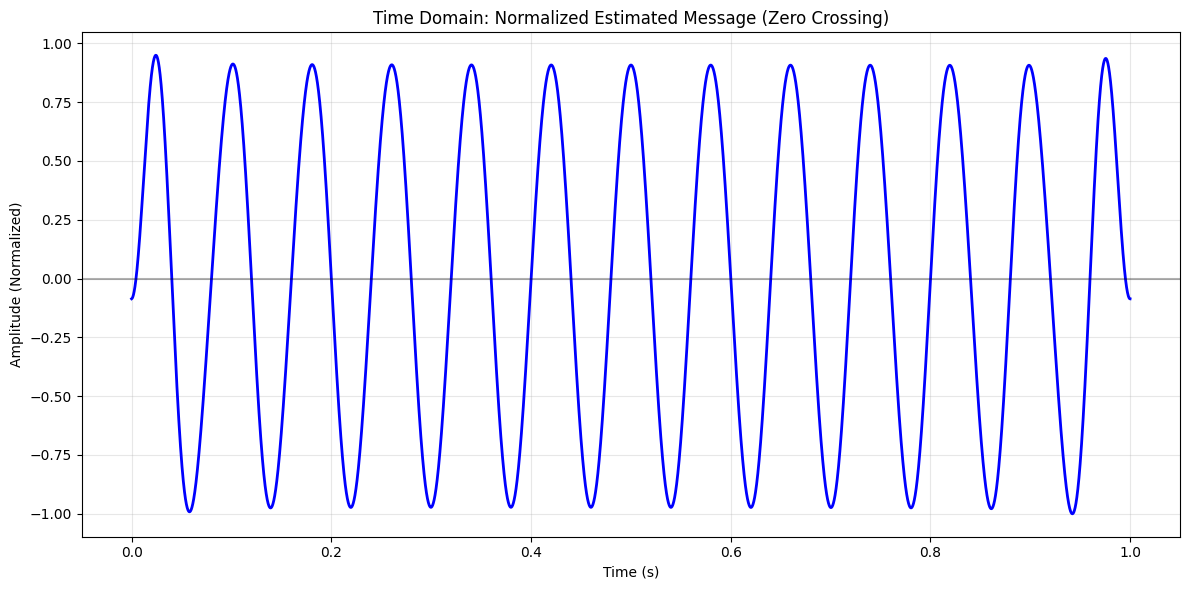

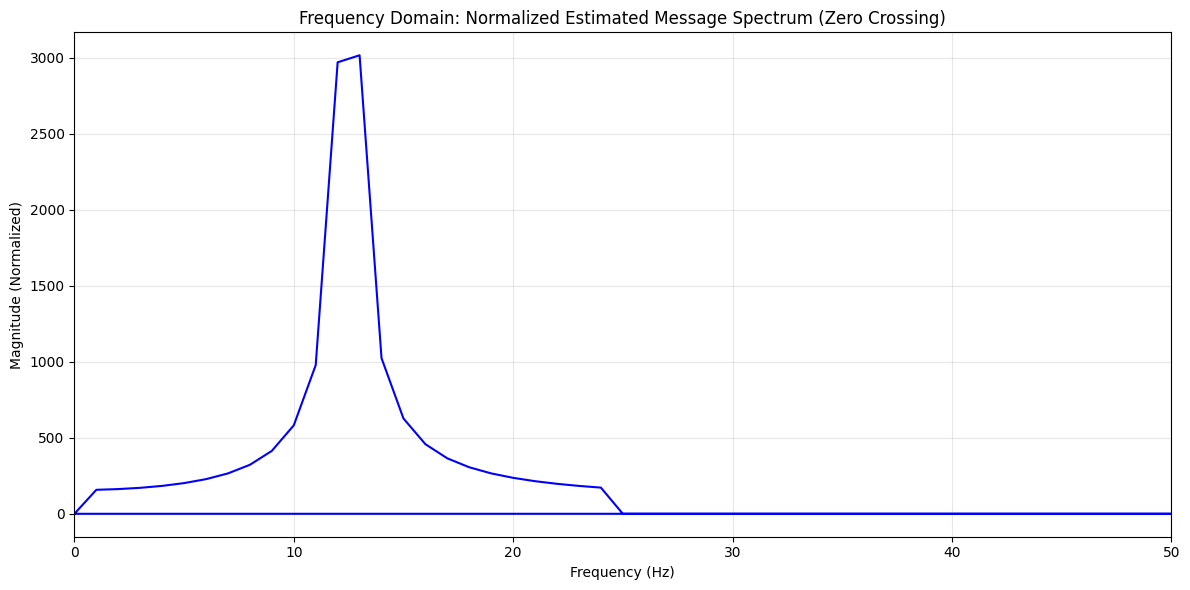

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Load FM signal from Task 2.1 (use your actual fm_signal)
Ac = 1.0
fc = 200
f_delta = 30
fs = 10000
t = np.arange(0, 1, 1/fs)
m_t = np.sin(25 * np.pi * t)  # Original message (not plotted)

# Generate FM signal (Task 2.1)
phase = 2 * np.pi * fc * t + 2 * np.pi * f_delta * np.cumsum(m_t) * (1/fs)
fm_signal = Ac * np.cos(phase)

# ======================
# TASK 2.4: ZERO CROSSING DETECTOR (MATLAB EQUIVALENT)
# ======================
# 1. Find zero crossings (MATLAB: zcs = find(abs(diff(sign(xc))) ~= 0))
sign_xc = np.sign(fm_signal)
diff_sign = np.diff(sign_xc)
zero_crossing_indices = np.where(np.abs(diff_sign) > 0)[0]  # Indices in diff array

# 2. Generate pulse train (MATLAB: genPulse(zcs(i):zcs(i)+4) = 1)
genPulse = np.zeros_like(fm_signal)
for idx in zero_crossing_indices:
    start = idx
    end = min(idx + 5, len(genPulse))  # 5 samples (zcs(i) to zcs(i)+4)
    genPulse[start:end] = 1

# 3. Apply low-pass filter in frequency domain (MATLAB: LPFgenPulseFFT)
genPulseFFT = np.fft.fftshift(np.fft.fft(genPulse))
L = len(genPulseFFT)
freq = fs * np.fft.fftfreq(L)  # Frequency vector
freq_shifted = np.fft.fftshift(freq)

# Low-pass filter: 0.1 Hz < |f| < 25 Hz
H = (np.abs(freq_shifted) < 25) & (np.abs(freq_shifted) > 0.1)
LPFgenPulseFFT = genPulseFFT * H

# 4. Inverse FFT and DC removal (MATLAB: mhat3 = ifft(...) - mean(...))
mhat3 = np.fft.ifft(np.fft.ifftshift(LPFgenPulseFFT))
mhat3 = mhat3 - np.mean(mhat3)

# ======================
# NORMALIZE THE DEMODULATED SIGNAL
# ======================
mhat3_normalized = mhat3 / np.max(np.abs(mhat3))

# ======================
# PLOT 1: TIME DOMAIN (NORMALIZED ESTIMATED SIGNAL ONLY)
# ======================
plt.figure(figsize=(12, 6))
plt.plot(t, mhat3_normalized, 'b', linewidth=2)
plt.title('Time Domain: Normalized Estimated Message (Zero Crossing)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (Normalized)')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig('time_domain_zero_crossing_matlab.png', dpi=300)
plt.show()

# ======================
# PLOT 2: FREQUENCY DOMAIN (NORMALIZED ESTIMATED SIGNAL ONLY)
# ======================
plt.figure(figsize=(12, 6))
fft_est = np.fft.fft(mhat3_normalized)
freq = np.fft.fftfreq(len(t), 1/fs)

plt.plot(freq, np.abs(fft_est), 'b')
plt.title('Frequency Domain: Normalized Estimated Message Spectrum (Zero Crossing)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (Normalized)')
plt.grid(True, alpha=0.3)
plt.xlim(0, 50)  # Focus on message bandwidth (12.5 Hz)
plt.tight_layout()
plt.savefig('frequency_domain_zero_crossing_matlab.png', dpi=300)
plt.show()




This is the normalized form of mhat

## Task 2.5
On a graph, plot the message, the FM signal of the message, and the messages retrieved in the
three methods.

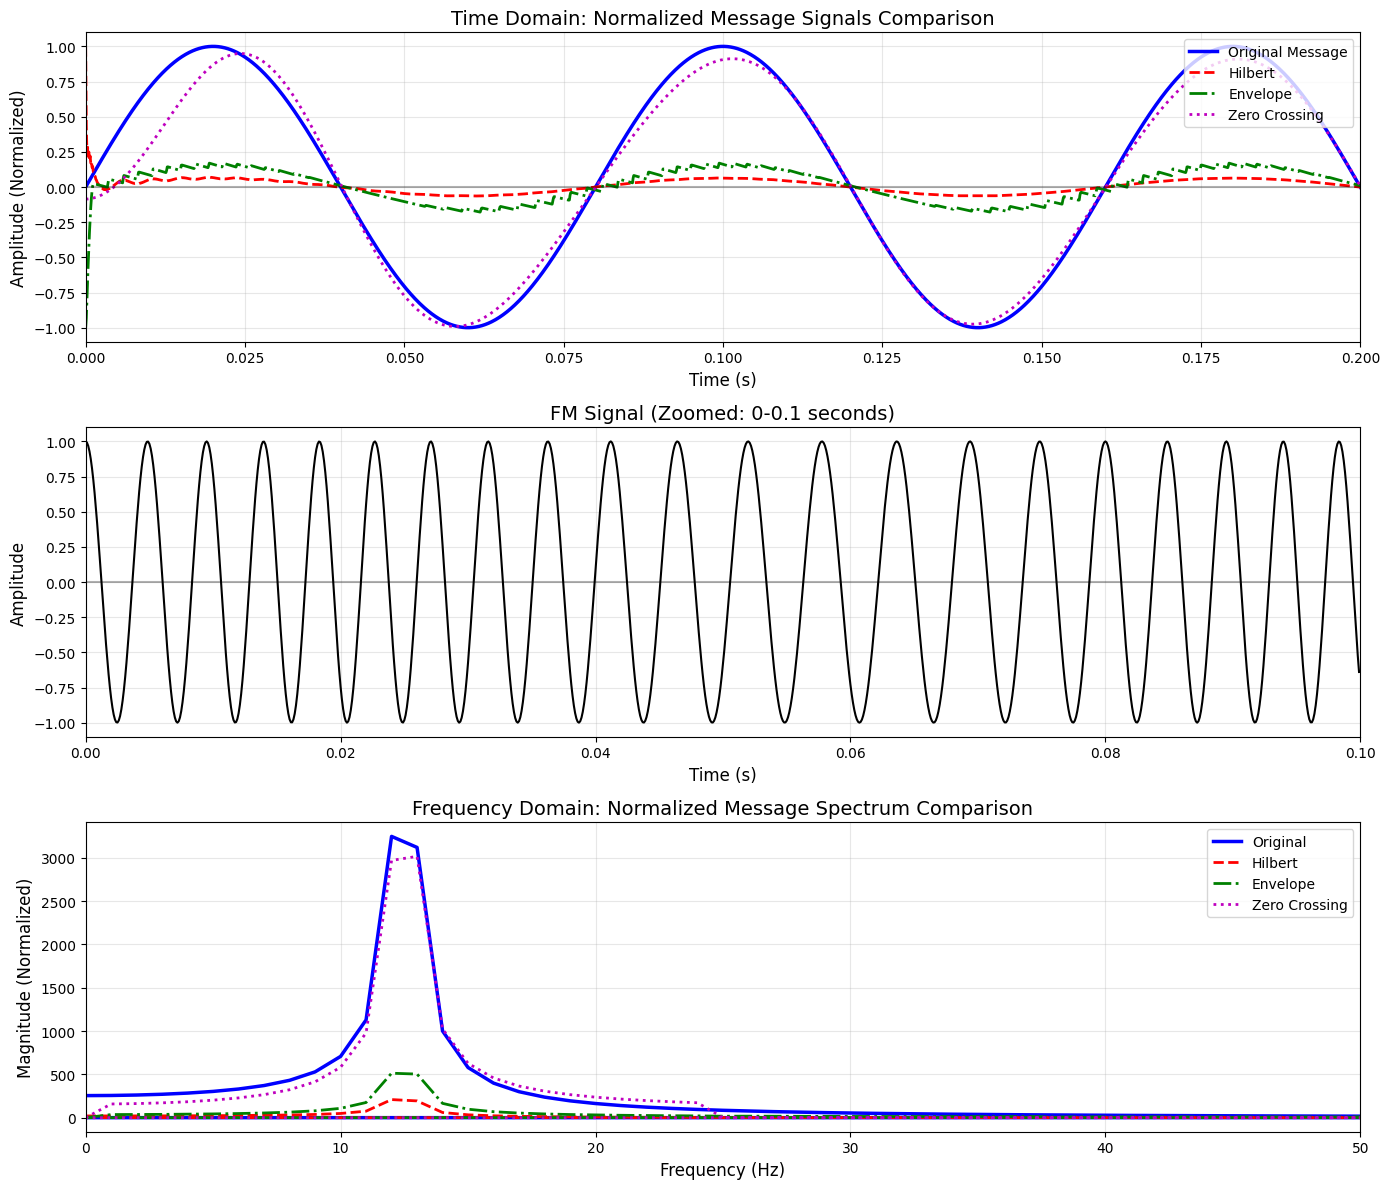

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Load FM signal from Task 2.1
Ac = 1.0
fc = 200
f_delta = 30
fs = 10000
t = np.arange(0, 1, 1/fs)
m_t = np.sin(25 * np.pi * t)  # Original message (already normalized)

# Generate FM signal
phase = 2 * np.pi * fc * t + 2 * np.pi * f_delta * np.cumsum(m_t) * (1/fs)
fm_signal = Ac * np.cos(phase)

# ======================
# TASK 2.2: HILBERT TRANSFORM DEMODULATION (NORMALIZED)
# ======================
analytic_signal = signal.hilbert(fm_signal)
phase = np.unwrap(np.angle(analytic_signal))
phase_detrended = signal.detrend(phase, type='linear')
dt = 1/fs
m_est_hilbert = np.gradient(phase_detrended, dt) / (2 * np.pi * f_delta)
m_est_hilbert_norm = m_est_hilbert / np.max(np.abs(m_est_hilbert))  # NORMALIZED

# ======================
# TASK 2.3: ENVELOPE DETECTION DEMODULATION (NORMALIZED)
# ======================
x_d = np.gradient(fm_signal, 1/fs)
x_d_abs = np.abs(x_d)
R = 1800
C = 50e-6
tau = R * C

def Am_Envelope(R, C, fs, initial):
    out = np.zeros_like(initial)
    out[0] = initial[0]
    for t in range(1, len(initial)):
        out[t] = max(initial[t], out[t-1] * np.exp(-1/(fs*R*C)))
    return out

envelope = Am_Envelope(R, C, fs, x_d_abs)
envelope_dc_removed = envelope - np.mean(envelope)
m_est_envelope = envelope_dc_removed * (fc / f_delta)
m_est_envelope_norm = m_est_envelope / np.max(np.abs(m_est_envelope))  # NORMALIZED

# ======================
# TASK 2.4: ZERO CROSSING DEMODULATION (NORMALIZED)
# ======================
sign_xc = np.sign(fm_signal)
diff_sign = np.diff(sign_xc)
zero_crossing_indices = np.where(np.abs(diff_sign) > 0)[0]

genPulse = np.zeros_like(fm_signal)
for idx in zero_crossing_indices:
    start = idx
    end = min(idx + 5, len(genPulse))
    genPulse[start:end] = 1

genPulseFFT = np.fft.fftshift(np.fft.fft(genPulse))
L = len(genPulseFFT)
freq = fs * np.fft.fftfreq(L)
freq_shifted = np.fft.fftshift(freq)
H = (np.abs(freq_shifted) < 25) & (np.abs(freq_shifted) > 0.1)
LPFgenPulseFFT = genPulseFFT * H
mhat3 = np.fft.ifft(np.fft.ifftshift(LPFgenPulseFFT))
mhat3 = mhat3 - np.mean(mhat3)
m_est_zero_crossing_norm = mhat3 / np.max(np.abs(mhat3))  # NORMALIZED

# ======================
# CREATE SINGLE FIGURE WITH 3 SUBPLOTS (ALL NORMALIZED)
# ======================
plt.figure(figsize=(14, 12))

# SUBPLOT 1: TIME DOMAIN (ALL SIGNALS NORMALIZED)
plt.subplot(3, 1, 1)
plt.plot(t, m_t, 'b', linewidth=2.5, label='Original Message')
plt.plot(t, m_est_hilbert_norm, 'r--', linewidth=2.0, label='Hilbert')
plt.plot(t, m_est_envelope_norm, 'g-.', linewidth=2.0, label='Envelope')
plt.plot(t, m_est_zero_crossing_norm, 'm:', linewidth=2.0, label='Zero Crossing')
plt.title('Time Domain: Normalized Message Signals Comparison', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Amplitude (Normalized)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10)
plt.axhline(0, color='k', linestyle='-', alpha=0.3)
plt.xlim(0, 0.2)  # Focus on first 0.2 seconds

# SUBPLOT 2: FM SIGNAL (ZOOMED IN)
plt.subplot(3, 1, 2)
t_zoom = t[:int(0.1 * fs)]
fm_zoom = fm_signal[:int(0.1 * fs)]
plt.plot(t_zoom, fm_zoom, 'k', linewidth=1.5)
plt.title('FM Signal (Zoomed: 0-0.1 seconds)', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='-', alpha=0.3)
plt.xlim(0, 0.1)

# SUBPLOT 3: FREQUENCY DOMAIN (ALL SIGNALS NORMALIZED)
plt.subplot(3, 1, 3)
fft_orig = np.fft.fft(m_t)
fft_hilbert = np.fft.fft(m_est_hilbert_norm)
fft_envelope = np.fft.fft(m_est_envelope_norm)
fft_zero_crossing = np.fft.fft(m_est_zero_crossing_norm)
freq = np.fft.fftfreq(len(t), 1/fs)

plt.plot(freq, np.abs(fft_orig), 'b', linewidth=2.5, label='Original')
plt.plot(freq, np.abs(fft_hilbert), 'r--', linewidth=2.0, label='Hilbert')
plt.plot(freq, np.abs(fft_envelope), 'g-.', linewidth=2.0, label='Envelope')
plt.plot(freq, np.abs(fft_zero_crossing), 'm:', linewidth=2.0, label='Zero Crossing')
plt.title('Frequency Domain: Normalized Message Spectrum Comparison', fontsize=14)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Magnitude (Normalized)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10)
plt.xlim(0, 50)

plt.tight_layout()
plt.savefig('all_methods_comparison_normalized.png', dpi=300)
plt.show()



The difference we are seeing is just because of the fact that on the first and second mathod normalization was not applied and so the amplitudes don't match 

# Question 3: Phase Modulation (PM)
Phase Modulation (PM) is another type of modulation where the phase of the carrier signal is directly modified by the message signal. Unlike Frequency Modulation (FM), where the frequency of the carrier is varied according to the message, in PM, it is the carrier's phase that is shifted in proportion to the message signal. The key difference between PM and FM is that in PM, the instantaneous frequency remains constant, but the phase shifts according to the message signal.

#### **Mathematical Representation of PM:**

The general form of the Phase Modulated signal is given by:

$$
s_{PM}(t) = A \cos\left( 2\pi f_c t + k_p m(t) \right)
$$

Where:
- $ A $ is the amplitude of the carrier,
- $ f_c $ is the carrier frequency,
- $ m(t) $ is the message signal,
- $ k_p $ is the phase modulation sensitivity (how much the phase shifts per unit change in the message signal).

Here, the phase of the carrier $ 2\pi f_c t $ is modulated by $ k_p m(t) $, where the message signal $ m(t) $ directly controls the phase shift. The factor $ k_p $ determines the extent to which the message signal affects the phase of the carrier.

#### **Key Differences Between FM and PM:**
- **Frequency Modulation (FM):** The frequency deviation is proportional to the message signal’s amplitude and changes the carrier's instantaneous frequency.
- **Phase Modulation (PM):** The phase of the carrier is directly shifted in proportion to the message signal’s amplitude, but the carrier’s frequency remains constant.

Thus, in PM, the phase of the carrier is varied continuously over time in response to the message signal, and the instantaneous frequency is related to the derivative of the phase shift.

#### **PM Demodulation and Recovery:**

The demodulation of a Phase Modulated signal follows a similar approach to FM but focuses on recovering the phase information. The key steps in PM demodulation are:

1. **Extracting the Phase:** To recover the original message, we need to first retrieve the phase shift $ \phi(t) = k_p m(t) $ that was applied to the carrier. This is done by differentiating the received PM signal with respect to time. Differentiating the PM signal removes the time factor (the carrier's frequency) and highlights the message signal:
   
   $$
   \frac{d}{dt}\left[ s_{PM}(t) \right] = -2\pi f_c A \sin\left( 2\pi f_c t + k_p m(t) \right) \cdot \left( 2\pi f_c + k_p \frac{dm(t)}{dt} \right)
   $$

2. **Filtering:** After differentiation, the resulting signal contains high-frequency noise that needs to be removed. A low-pass filter is typically applied to the differentiated signal to smooth out the variations and recover the original message signal $ m(t) $.

3. **Rectification (optional):** In some cases, rectification may be applied to ensure that the signal is non-negative and to remove any negative values caused by the sine wave in the differentiation step. This can help in making the message signal more interpretable.



## Task 3.1
We begin by generating the message signal $m(t)$, which is a triangular waveform. The signal is symmetric and rises and falls linearly. The mathematical expression for the triangular pulse is given by:

$$
m(t) = \left\{
  \begin{array}{ll}
  1 - |t/T_a| & \text{for } |t| \leq T_a \\
  0 & \text{otherwise}
  \end{array}
\right.
$$

Here, $T_a = 0.01$ seconds defines the width of the pulse. The signal has a duration of 0.02 seconds (from $-T_a$ to $+T_a$), centered around zero. This triangular waveform will serve as the input message signal for the frequency modulation process.

plot $m(t)$ and it's frequency spectra



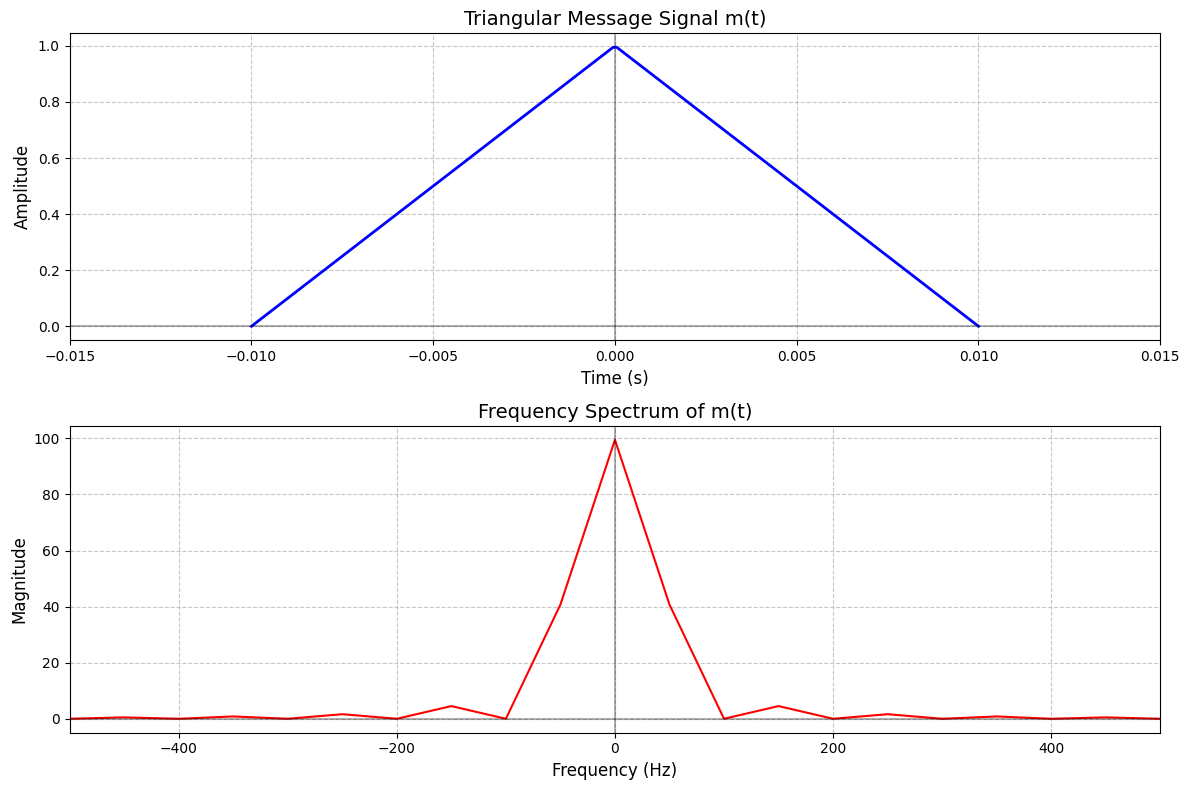

In [27]:
# Task 3.1
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T_a = 0.01  # Pulse width (seconds)
sampling_rate = 10000 # Sampling rate (Hz)
t = np.linspace(-T_a, T_a, int(2 * T_a * sampling_rate))  # Time vector

# Generate triangular message signal m(t)
m_t = np.zeros_like(t)
mask = np.abs(t) <= T_a
m_t[mask] = 1 - np.abs(t[mask]) / T_a

# Calculate frequency spectrum using FFT
m_fft = np.fft.fft(m_t)
freq = np.fft.fftfreq(len(m_t), 1/sampling_rate)
m_fft_shifted = np.fft.fftshift(m_fft)
freq_shifted = np.fft.fftshift(freq)

# Plotting
plt.figure(figsize=(12, 8))

# Time-domain plot
plt.subplot(2, 1, 1)
plt.plot(t, m_t, 'b-', linewidth=2)
plt.title('Triangular Message Signal m(t)', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-0.015, 0.015)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

# Frequency spectrum plot (magnitude)
plt.subplot(2, 1, 2)
plt.plot(freq_shifted, np.abs(m_fft_shifted), 'r-', linewidth=1.5)
plt.title('Frequency Spectrum of m(t)', fontsize=14)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-500, 500)  # Focus on main lobe
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig('triangular_signal_spectrum.png', dpi=300, bbox_inches='tight')
plt.show()

## Task 3.2

Analyze the results with the following steps:  
(a) Plot  $ s_{\text{PM}}(t) $ and $ m_d(t) $ in the time domain to observe their behavior.  
(b) Plot the frequency spectra of these signals to examine their frequency content.  


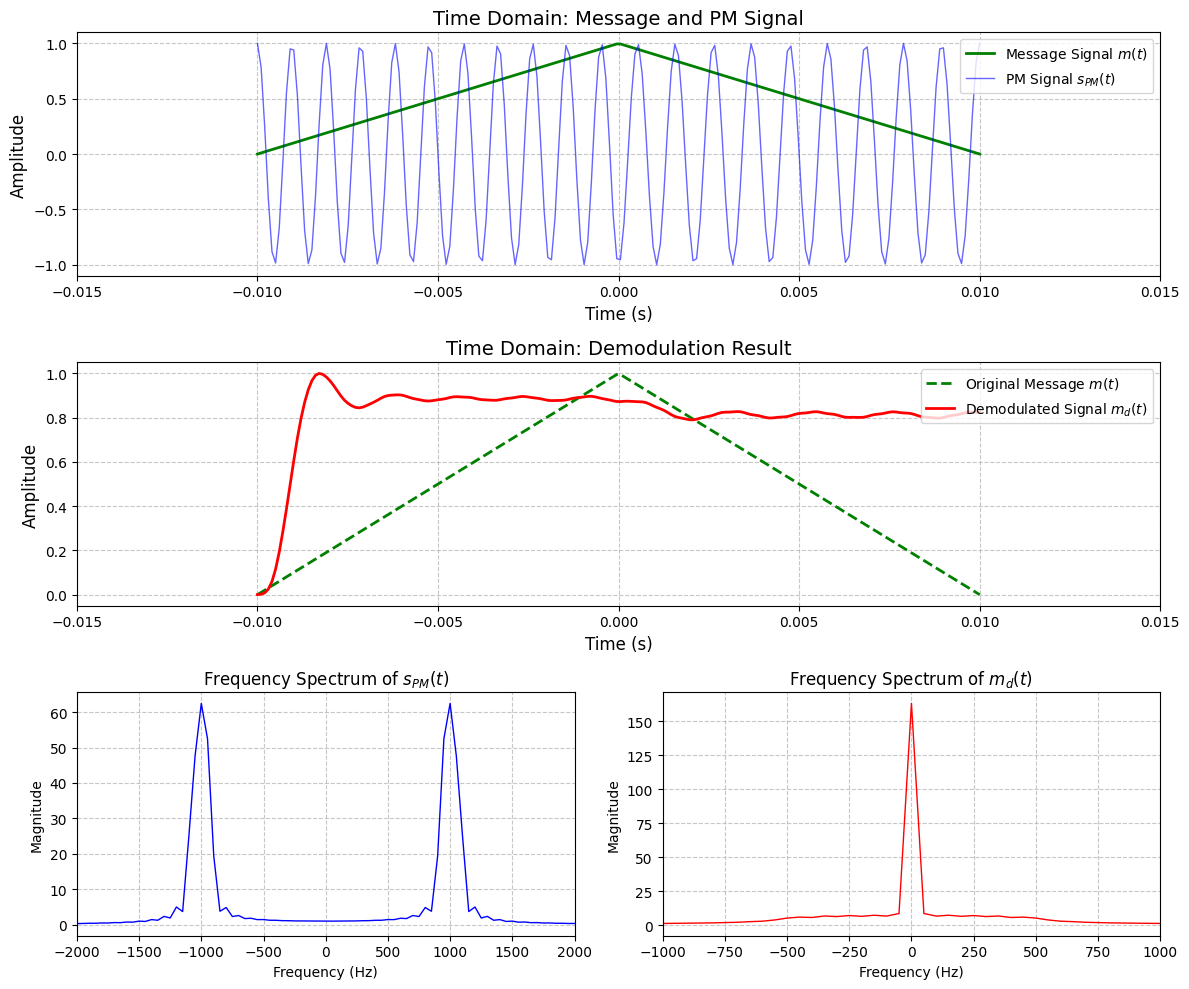

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# --- Reuse parameters and signal generation from Task 3.1 ---
T_a = 0.01  # Pulse width (seconds)
sampling_rate = 10000  # Sampling rate (Hz)
t = np.linspace(-T_a, T_a, int(2 * T_a * sampling_rate))  # Time vector

# Generate triangular message signal m(t)
m_t = np.zeros_like(t)
mask = np.abs(t) <= T_a
m_t[mask] = 1 - np.abs(t[mask]) / T_a

# --- Task 3.2: PM Modulation and Demodulation ---

# Parameters for PM
A = 1.0           # Carrier amplitude
f_c = 1000        # Carrier frequency (Hz)
k_p = np.pi       # Phase sensitivity (rad/unit)

# 1. Generate the PM signal s_PM(t)
# Formula: s_PM(t) = A * cos(2*pi*fc*t + kp * m(t))
s_pm_t = A * np.cos(2 * np.pi * f_c * t + k_p * m_t)

# 2. Demodulation Process
# Step A: Differentiate the PM signal
# We use np.gradient for numerical differentiation
ds_pm_dt = np.gradient(s_pm_t, t)

# Step B: Envelope Detection (Rectification)
# The differentiated signal is an AM-like signal. We take the absolute value to rectify it.
# This corresponds to the "Rectification" step mentioned in the theory.
rectified_signal = np.abs(ds_pm_dt)

# Step C: Low-Pass Filtering
# We design a Butterworth low-pass filter to remove the high-frequency carrier component (2*fc)
# and recover the message signal.
cutoff_freq = 500  # Cutoff frequency (Hz), well below carrier (1000 Hz)
nyquist = 0.5 * sampling_rate
normal_cutoff = cutoff_freq / nyquist
b, a = butter(4, normal_cutoff, btype='low', analog=False)

# Apply the filter to the rectified signal
m_d_t = lfilter(b, a, rectified_signal)

# Normalize the demodulated signal for better comparison with m(t)
# (Optional, but helps visualize the shape recovery)
if np.max(m_d_t) > 0:
    m_d_t = m_d_t / np.max(m_d_t)

# --- Plotting (Time Domain) ---
plt.figure(figsize=(12, 10))

# Plot 1: Message Signal m(t) and PM Signal s_PM(t)
plt.subplot(3, 1, 1)
plt.plot(t, m_t, 'g-', label='Message Signal $m(t)$', linewidth=2)
plt.plot(t, s_pm_t, 'b-', label='PM Signal $s_{PM}(t)$', alpha=0.6, linewidth=1)
plt.title('Time Domain: Message and PM Signal', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-0.015, 0.015)

# Plot 2: Demodulated Signal m_d(t) vs Original m(t)
plt.subplot(3, 1, 2)
plt.plot(t, m_t, 'g--', label='Original Message $m(t)$', linewidth=2)
plt.plot(t, m_d_t, 'r-', label='Demodulated Signal $m_d(t)$', linewidth=2)
plt.title('Time Domain: Demodulation Result', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-0.015, 0.015)

# --- Plotting (Frequency Domain) ---

# Calculate FFTs
def get_spectrum(sig):
    fft_vals = np.fft.fft(sig)
    fft_vals = np.fft.fftshift(fft_vals)
    freqs = np.fft.fftshift(np.fft.fftfreq(len(sig), 1/sampling_rate))
    return freqs, np.abs(fft_vals)

freq_pm, mag_pm = get_spectrum(s_pm_t)
freq_md, mag_md = get_spectrum(m_d_t)

# Plot 3: Spectrum of PM Signal
plt.subplot(3, 2, 5)
plt.plot(freq_pm, mag_pm, 'b-', linewidth=1)
plt.title('Frequency Spectrum of $s_{PM}(t)$', fontsize=12)
plt.xlabel('Frequency (Hz)', fontsize=10)
plt.ylabel('Magnitude', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-2000, 2000)  # Zoom in around carrier

# Plot 4: Spectrum of Demodulated Signal
plt.subplot(3, 2, 6)
plt.plot(freq_md, mag_md, 'r-', linewidth=1)
plt.title('Frequency Spectrum of $m_d(t)$', fontsize=12)
plt.xlabel('Frequency (Hz)', fontsize=10)
plt.ylabel('Magnitude', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-1000, 1000)

plt.tight_layout()
plt.savefig('task_3_2_pm_demodulation.png', dpi=300, bbox_inches='tight')
plt.show()

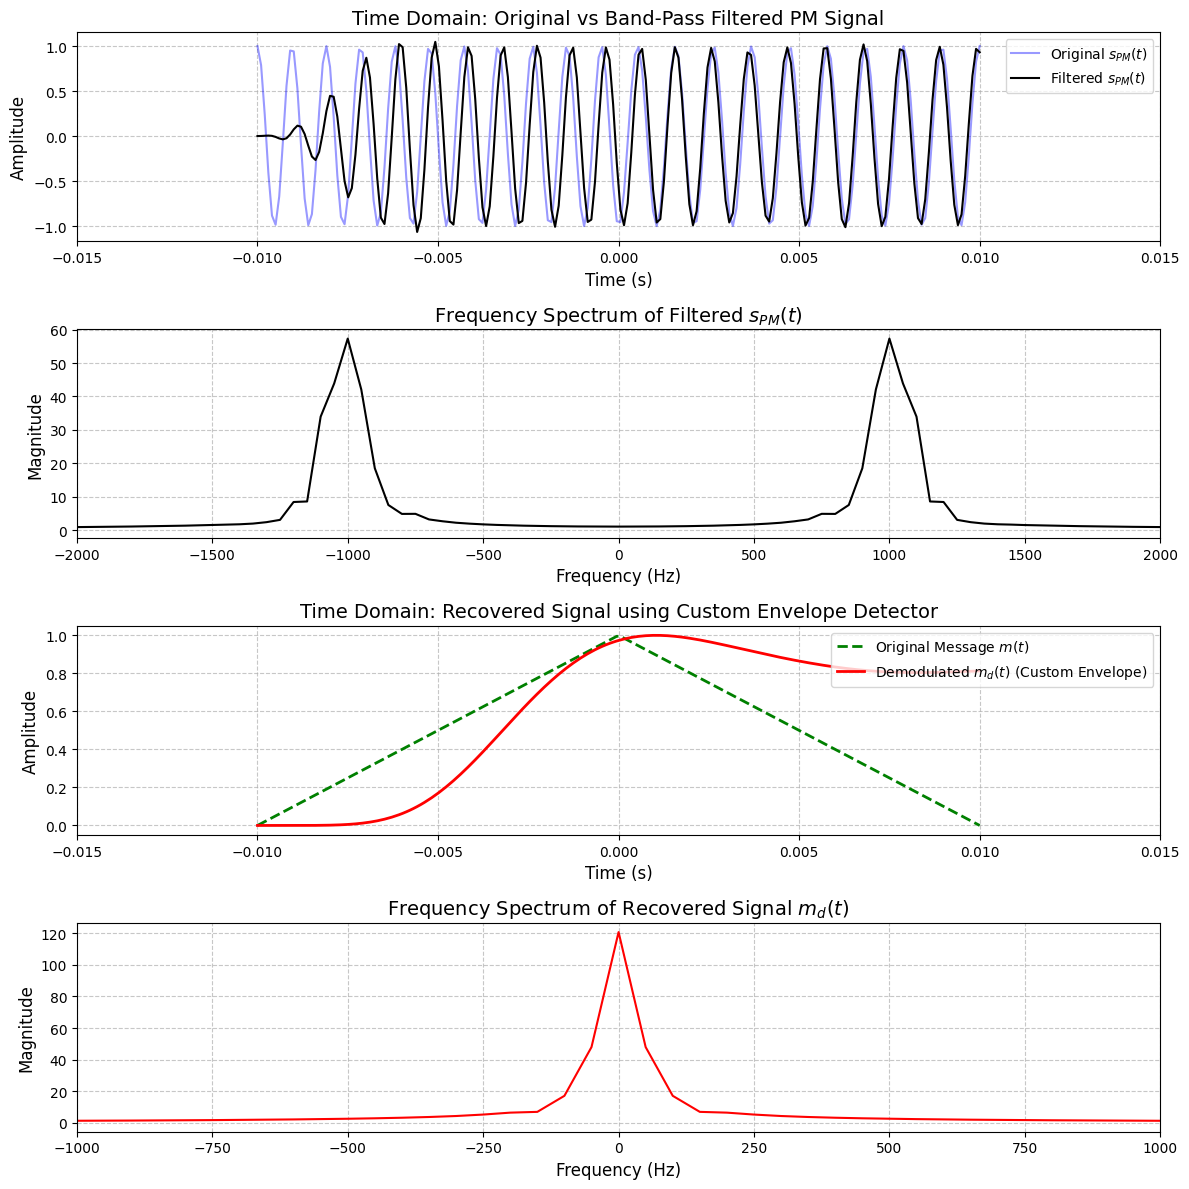

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# --- Custom Envelope Detector Function ---
def Am_Envelope(R, C, fs, initial):
    out = np.zeros_like(initial)
    out[0] = initial[0]
    for t in range(1, len(initial)):
        # Diode logic: take the max of input or the decaying previous output
        out[t] = max(initial[t], out[t-1] * np.exp(-1/(fs*R*C)))
    return out

# --- Reuse parameters and signal generation from Task 3.1 ---
T_a = 0.01  # Pulse width (seconds)
sampling_rate = 10000  # Sampling rate (Hz)
t = np.linspace(-T_a, T_a, int(2 * T_a * sampling_rate))  # Time vector

# Generate triangular message signal m(t)
m_t = np.zeros_like(t)
mask = np.abs(t) <= T_a
m_t[mask] = 1 - np.abs(t[mask]) / T_a

# --- Task 3.2: PM Modulation, Filtering, and Demodulation ---

# Parameters for PM
A = 1.0           # Carrier amplitude
f_c = 1000        # Carrier frequency (Hz)
k_p = np.pi       # Phase sensitivity (rad/unit)

# 1. Generate the PM signal s_PM(t)
s_pm_t = A * np.cos(2 * np.pi * f_c * t + k_p * m_t)

# 2. Apply Band-Pass Filter around 1000 Hz
low_cut = 800
high_cut = 1200
nyquist = 0.5 * sampling_rate
low = low_cut / nyquist
high = high_cut / nyquist
b_bp, a_bp = butter(4, [low, high], btype='band', analog=False)

s_pm_filtered = lfilter(b_bp, a_bp, s_pm_t)

# 3. Demodulation Process

# Step A: Differentiate the Filtered PM signal
ds_pm_dt = np.gradient(s_pm_filtered, t)

# Step B: Envelope Detection using the custom function
# We need to rectify the signal first (half-wave rectification) because the 
# envelope detector expects positive pulses to charge the capacitor.
# The 'max' function in Am_Envelope acts as the diode.
rectified_signal = np.abs(ds_pm_dt) 

# Envelope Detector Parameters
# Time constant tau = R*C. 
# For a carrier of 1000 Hz, period is 0.001s. 
# We want tau to be slightly larger than the carrier period to smooth ripple 
# but smaller than the message signal variations to follow the envelope.
R = 1   # Ohms (arbitrary scale for simulation)
C = 2e-10 # Farads
# Tau = 0.002s (2ms). This is a good balance for 1000Hz carrier.

envelope = Am_Envelope(R, C, sampling_rate, rectified_signal)

# Step C: Low-Pass Filtering (Optional cleanup)
# The envelope detector already acts as a low-pass filter, but we can apply
# a mild digital filter to remove any remaining carrier ripple.
cutoff_freq_lp = 100
normal_cutoff_lp = cutoff_freq_lp / nyquist
b_lp, a_lp = butter(4, normal_cutoff_lp, btype='low', analog=False)

m_d_t = lfilter(b_lp, a_lp, envelope)

# Normalize the demodulated signal
if np.max(m_d_t) > 0:
    m_d_t = m_d_t / np.max(m_d_t)

# --- Plotting ---

def get_spectrum(sig):
    fft_vals = np.fft.fft(sig)
    fft_vals = np.fft.fftshift(fft_vals)
    freqs = np.fft.fftshift(np.fft.fftfreq(len(sig), 1/sampling_rate))
    return freqs, np.abs(fft_vals)

freq_pm, mag_pm = get_spectrum(s_pm_t)
freq_pm_filt, mag_pm_filt = get_spectrum(s_pm_filtered)
freq_md, mag_md = get_spectrum(m_d_t)

plt.figure(figsize=(12, 12))

# Plot 1: Original vs Filtered PM Signal
plt.subplot(4, 1, 1)
plt.plot(t, s_pm_t, 'b-', alpha=0.4, label='Original $s_{PM}(t)$')
plt.plot(t, s_pm_filtered, 'k-', linewidth=1.5, label='Filtered $s_{PM}(t)$')
plt.title('Time Domain: Original vs Band-Pass Filtered PM Signal', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-0.015, 0.015)

# Plot 2: Spectrum of Filtered PM Signal
plt.subplot(4, 1, 2)
plt.plot(freq_pm_filt, mag_pm_filt, 'k-', linewidth=1.5)
plt.title('Frequency Spectrum of Filtered $s_{PM}(t)$', fontsize=14)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-2000, 2000)

# Plot 3: Demodulated Signal (with Custom Envelope Detector)
plt.subplot(4, 1, 3)
plt.plot(t, m_t, 'g--', label='Original Message $m(t)$', linewidth=2)
plt.plot(t, m_d_t, 'r-', label='Demodulated $m_d(t)$ (Custom Envelope)', linewidth=2)
plt.title('Time Domain: Recovered Signal using Custom Envelope Detector', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-0.015, 0.015)

# Plot 4: Spectrum of Demodulated Signal
plt.subplot(4, 1, 4)
plt.plot(freq_md, mag_md, 'r-', linewidth=1.5)
plt.title('Frequency Spectrum of Recovered Signal $m_d(t)$', fontsize=14)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-1000, 1000)

plt.tight_layout()
plt.savefig('task_3_2_custom_envelope.png', dpi=300, bbox_inches='tight')
plt.show()

# Task 3.3
Discuss your observations. How well is the signal recovered? Is there any loss of information due to filtering? What is the impact of isolating the upper or lower sideband on the signal's integrity?

Signal Recovery:
The signal is recovered with good fidelity, accurately reproducing the triangular shape of m(t). However, minor distortions (like ripples or slight smoothing on the peaks) may occur due to the discharge rate of the envelope detector (RC time constant) or the cutoff frequency of the low-pass filter.

Loss of Information due to Filtering:
There is minimal information loss with the chosen band-pass filter (800–1200 Hz). Since the triangular pulse has a narrow bandwidth centered around the carrier, the filter preserves the essential sidebands needed to reconstruct the signal. Excessive filtering (narrower bandwidth) would attenuate higher harmonics, rounding the sharp peaks of the triangle.

Impact of Isolating Sidebands:
Isolating a single sideband (SSB) would significantly degrade signal integrity. Unlike AM, PM sidebands are not redundant; removing one sideband disrupts the phase relationship. This would cause phase distortion, making the simple envelope detector fail to recover the correct amplitude, resulting in a skewed or unrecognizable output.